# [Py4Hw User Guide](../UserGuide.ipynb) > 4.2 Clocked Processes
###  [Next: 4.3 Clock Enabling](ClockEnable.ipynb)

Some processes are very easily described sequentially, as done in standard programming languages. Most programmers are used to understand computer behaviour in this way.

In HDLs you require to describe how clock advances.

For instance, in SystemC, this is done within SC_CTHREAD using the wait method.

Between two clock advances everything occurs simultaneously at the hardware level.

In py4hw this can be achived by combining behavioural sequential circuits (implementing the **clock** method) and python generators (**yield** and **yield from** statements). 

When an object is created a co-rutine is started which automatically is block when a first **yield** is reached.

The corutine **next** value is called inside the clock method of the circuit, unblocking the corutine until a next **yield** statement is found.

The following example illustrates this design method. It generates a pulse that starts being active just one cycle, then two, then three, and so on and so forth up to ten, and then restarts the cycle.

In [1]:
import py4hw

In [7]:
class ComplexStimuli(py4hw.Logic):
    
    def __init__(self, parent, name, q):
        super().__init__(parent, name)
        
        self.vq = 0
        self.q = self.addOut('q', q)
        
        self.co = self.run()
        
    def run(self):
        a = 0
        while (True):
            yield from self.pulse(a)
            a += 1
            if (a > 10):
                a = 0
            
    def pulse(self, w):
        # at least, 1 zero
        self.q.prepare( 0)
        yield
        
        for i in range(w):
            self.q.prepare(1)
            yield
            
    def clock(self):
        next(self.co)


In [25]:
sys = py4hw.HWSystem()
q = sys.wire('q')
count = sys.wire('count', 8)
reset = sys.wire('reset')

sti = ComplexStimuli(sys, 'sti', q)
py4hw.Not(sys, 'reset', q, reset)
py4hw.Counter(sys, 'count',  reset, q, count)


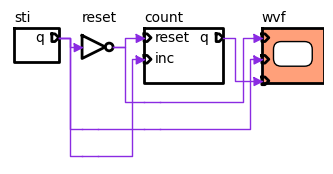

In [26]:
wvf = py4hw.Waveform(sys, 'wvf', [reset, q, count])

sch = py4hw.Schematic(sys)
sch.draw()

In [27]:
sys.getSimulator().clk(30)

In [28]:
wvf.draw_wavedrom()

### Summary
- Clocked processes (we also call them Algorithmic models) allow to describe circuit behaviour in a very familiar programatic way
- They still allow to specify the clock boundaries
- They are typically used to define stimuli in testbenches
- We are working on making them synthesizable as well